# ANÁLISIS DE DATOS

En este notebook, vamos a realizar distintos análisis con los datos ya recolectados y limpios.

In [2]:
# librerías a utilizar
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import time
from pathlib import Path

In [3]:
ruta_unificada_micro = Path('..', 'csv_unificado_buses') / 'unified_bus_data.csv'
ruta_unificada_metro = Path('..', 'csv_unificado_metro') / 'unified_metro_data.csv'


# Lectura de archivos
Leemos cada archivo correspondiente:

In [4]:
# Archivo micros
metro_data = pd.read_csv(ruta_unificada_metro)
metro_data.head(3)

,line_id,station_id,name,status_code,status_description,date
0,L1,san-pablo,San Pablo,0,Estación Operativa,2025-10-12 17:07:54.225175
1,L1,neptuno,Neptuno,0,Estación Operativa,2025-10-12 17:07:54.225191
2,L1,pajaritos,Pajaritos,0,Estación Operativa,2025-10-12 17:07:54.225193


In [5]:
# Archivo metro
recorridos = pd.read_csv(ruta_unificada_micro)
recorridos.head(3)

,bus_stop_code,route_id,bus_id,meters_distance,min_arrival_time,max_arrival_time,id,codinfra,comuna,nombre_par,n_servicios,servicios,lan,lon,hour,date_only
0,PC96,216,VJWZ-95,4427,12,16,1244,L-17-16-25-SN,LAS CONDES,Av. Manquehue Norte / esq. Los Militares,2,216;C07,-70.568386,-33.405427,6,2025-11-01
1,PC96,216,SFWZ-21,11100,35,60,1244,L-17-16-25-SN,LAS CONDES,Av. Manquehue Norte / esq. Los Militares,2,216;C07,-70.568386,-33.405427,6,2025-11-01
2,PB169,B15,SPCG-69,5751,16,20,9567,L-4-23-15-SN,RECOLETA,Avenida Per� / esq. Desiderio Lemus,2,116;B15,-70.638409,-33.415770,6,2025-11-01


In [6]:
# Limpiamos según las horas a considerar para nuestro proyecto
recorridos_limpios = recorridos.copy()
recorridos_limpios = recorridos_limpios[recorridos_limpios['hour'].isin([x for x in range(6, 24, 2)])]
len(recorridos_limpios)

794035

In [7]:
# Vemos cómo están dados nuestros datos:
recorridos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 794035 entries, 0 to 832215
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   bus_stop_code     794035 non-null  object 
 1   route_id          794035 non-null  object 
 2   bus_id            794035 non-null  object 
 3   meters_distance   794035 non-null  int64  
 4   min_arrival_time  794035 non-null  int64  
 5   max_arrival_time  794035 non-null  int64  
 6   id                794035 non-null  int64  
 7   codinfra          794035 non-null  object 
 8   comuna            794035 non-null  object 
 9   nombre_par        794035 non-null  object 
 10  n_servicios       794035 non-null  int64  
 11  servicios         794035 non-null  object 
 12  lan               794035 non-null  float64
 13  lon               794035 non-null  float64
 14  hour              794035 non-null  int64  
 15  date_only         794035 non-null  object 
dtypes: float64(2), int64(6), 

In [8]:
# Revisamos todos los datos que tenemos en los paraderos limpios:
recorridos_limpios.columns

Index(['bus_stop_code', 'route_id', 'bus_id', 'meters_distance',
       'min_arrival_time', 'max_arrival_time', 'id', 'codinfra', 'comuna',
       'nombre_par', 'n_servicios', 'servicios', 'lan', 'lon', 'hour',
       'date_only'],
      dtype='object')

Entonces, el máximo de recorridos que pasan por uno de los paraderos contenidos en nuestro DataFrame es de 21.

# ANÁLISIS PARCIAL DE DATOS:
Lo primero que haremos, será crear DataFrames por sector de nuestros datos:

In [9]:
recorrido_poniente = recorridos_limpios[recorridos_limpios['comuna'].isin(['QUINTA NORMAL', 'CERRO NAVIA', 'MAIPÚ', 'CERRILLOS',
                                                     'ESTACIÓN CENTRAL', 'PUDAHUEL', 'RENCA', 'LO PRADO',
                                                     'PADRE HURTADO'])]
recorrido_poniente['comuna'].value_counts()

comuna
MAIPÚ               64446
PUDAHUEL            28867
ESTACIÓN CENTRAL    24787
QUINTA NORMAL       22422
RENCA               21455
CERRO NAVIA         19611
CERRILLOS           18328
LO PRADO            13230
PADRE HURTADO        1123
Name: count, dtype: int64

In [10]:
# COMUNAS ORIENTE
recorrido_oriente = recorridos_limpios[recorridos_limpios['comuna'].isin(['PROVIDENCIA', 'ÑUÑOA', 'LA REINA', 'LAS CONDES',
                                                                  'VITACURA', 'LO BARNECHEA', 'PEÑALOLÉN', 'MACUL',
                                                                  'LA FLORIDA', 'PUENTE ALTO'])]
recorrido_oriente['comuna'].value_counts()

comuna
PUENTE ALTO     59557
LA FLORIDA      40930
LAS CONDES      40029
PEÑALOLÉN       30017
ÑUÑOA           23968
PROVIDENCIA     20241
LA REINA        17424
MACUL           16376
VITACURA        12925
LO BARNECHEA     9469
Name: count, dtype: int64

In [11]:
# SECTOR SUR
recorrido_sur = recorridos_limpios[recorridos_limpios['comuna'].isin(['PEDRO AGUIRRE CERDA', 'SAN MIGUEL',
                                                              'SAN JOAQUÍN', 'LO ESPEJO', 'LA CISTERNA',
                                                              'LA GRANJA', 'SAN RAMÓN', 'EL BOSQUE',
                                                              'SAN BERNARDO', 'LA CISTERNA'])]
recorrido_sur['comuna'].value_counts()

comuna
SAN BERNARDO           30224
EL BOSQUE              18806
LA GRANJA              14604
LA CISTERNA            14283
LO ESPEJO              14199
SAN MIGUEL             13809
PEDRO AGUIRRE CERDA    11557
SAN RAMÓN              11098
SAN JOAQUÍN            11026
Name: count, dtype: int64

In [12]:
# SECTOR NORTE
recorrido_norte = recorridos_limpios[recorridos_limpios['comuna'].isin(['CONCHALÍ', 'HUECHURABA', 'INDEPENDENCIA', 'RECOLETA', 'QUILICURA'])]
recorrido_norte['comuna'].value_counts()

comuna
QUILICURA        27578
CONCHALÍ         17580
RECOLETA         17010
HUECHURABA       13218
INDEPENDENCIA    10810
Name: count, dtype: int64

In [13]:
# Revisaremos la mediana de los metros de distancia por sector
mediana_meters_norte = recorrido_norte.groupby(by='hour').agg({'meters_distance': 'median'})
mediana_meters_sur = recorrido_sur.groupby(by='hour').agg({'meters_distance': 'median'})
mediana_meters_oriente = recorrido_oriente.groupby(by='hour').agg({'meters_distance': 'median'})
mediana_meters_poniente = recorrido_poniente.groupby(by='hour').agg({'meters_distance': 'median'})
mediana_oriente_poniente = pd.merge(mediana_meters_oriente, mediana_meters_poniente, on='hour', how='outer')
mediana_oriente_poniente = mediana_oriente_poniente.set_axis(['Sector Oriente', 'Sector Poniente'], axis= 1)
mediana_norte_sur = pd.merge(mediana_meters_norte, mediana_meters_sur, on='hour', how='outer')
mediana_norte_sur = mediana_norte_sur.set_axis(['Sector Norte', 'Sector Sur'], axis= 1)
mediana_meters_sector = pd.merge(mediana_norte_sur, mediana_oriente_poniente, on='hour', how='outer')
mediana_meters_sector = mediana_meters_sector.sort_index()
# mediana_meters_sector.drop(mediana_meters_sector.index[2], inplace=True)
# mediana_meters_sector.drop(mediana_meters_sector.index[7], inplace=True)

In [14]:
mediana_meters_sector.head(10)

,Sector Norte,Sector Sur,Sector Oriente,Sector Poniente
hour,,,,
6,4114.5,3502.0,4057.0,4626.0
8,2444.0,2422.0,2297.0,2783.0
10,2809.5,2846.0,2627.0,3270.0
12,2872.0,2828.5,2736.0,3130.0
14,2772.0,2733.0,2622.0,3037.0
16,2838.0,2754.0,2603.5,2934.0
18,2362.0,2503.5,2324.0,2691.0
20,2624.0,2724.0,2574.0,2911.5
22,3376.0,3377.0,3387.5,3707.0


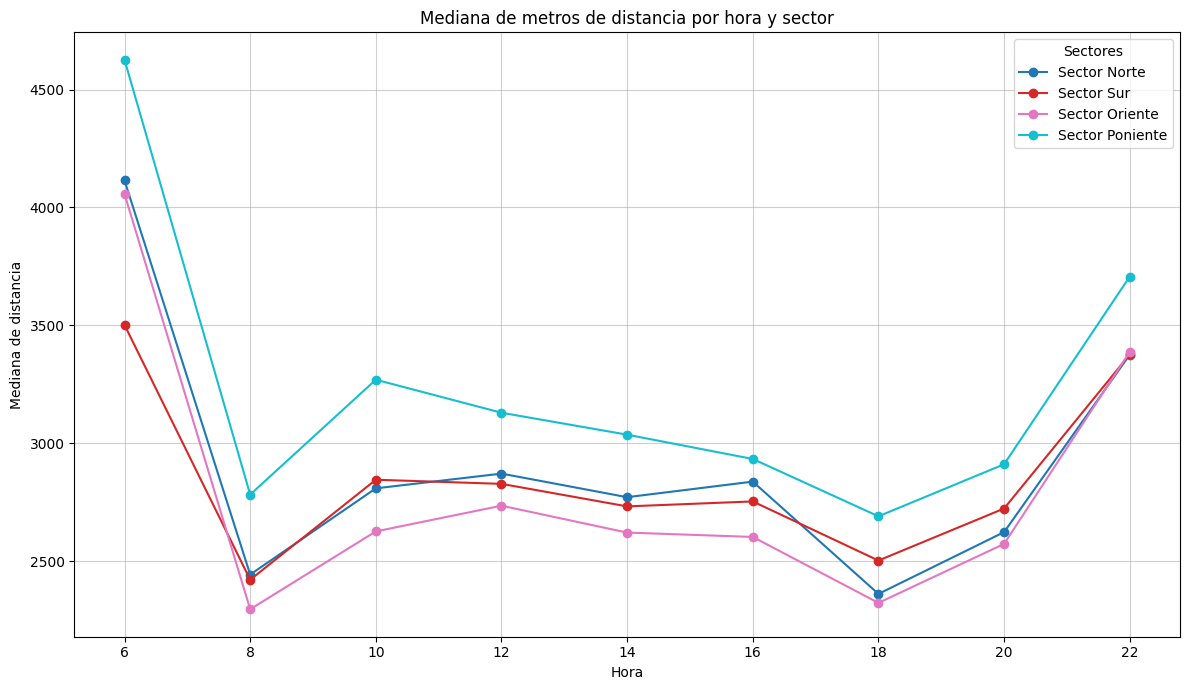

In [15]:
plt.figure(figsize=(12,7))

# Graficamos todas las columnas por sector
colormap = plt.colormaps['tab10']
for i, columna in enumerate(mediana_meters_sector.columns):
    plt.plot(mediana_meters_sector.index,
            mediana_meters_sector[columna],
            marker='o',
            label=columna,
            color = colormap(i / (len(mediana_meters_sector.columns) - 1)))

plt.title("Mediana de metros de distancia por hora y sector")
plt.xlabel("Hora")
plt.ylabel("Mediana de distancia")
plt.legend(title="Sectores")
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()

plt.show()

Ahora, según la mediana de los metros de distancia, veremos el mínimo y máximo de distancia por sector (y sus comunas) y la diferencia de estos.

In [16]:
distancia_norte = recorrido_norte.pivot_table(index='hour', columns='comuna', values='meters_distance', aggfunc='median')
distancia_norte['DISTANCIA_MIN'] = distancia_norte.min(axis=1)
distancia_norte['DISTANCIA_MAX'] = distancia_norte.max(axis=1)
distancia_norte['RANGO_DESBALANCE'] = distancia_norte.max(axis=1) - distancia_norte.min(axis=1) 
# distancia_norte.drop(distancia_norte.index[2], inplace=True)
# distancia_norte.drop(distancia_norte.index[7], inplace=True)
distancia_norte.sort_index()

comuna,CONCHALÍ,HUECHURABA,INDEPENDENCIA,QUILICURA,RECOLETA,DISTANCIA_MIN,DISTANCIA_MAX,RANGO_DESBALANCE
hour,,,,,,,,
6,4249.5,5094.0,3593.0,3718.0,4137.5,3593.0,5094.0,1501.0
8,2602.0,2896.0,2347.0,2271.0,2377.0,2271.0,2896.0,625.0
10,2954.0,2996.0,2454.0,2904.0,2665.0,2454.0,2996.0,542.0
12,3149.0,3262.0,2576.0,2754.0,2704.5,2576.0,3262.0,686.0
14,3155.5,3013.0,2725.0,2563.0,2629.0,2563.0,3155.5,592.5
16,3115.5,3019.0,2840.0,2537.0,2935.0,2537.0,3115.5,578.5
18,2537.0,2758.0,2535.0,2086.0,2390.0,2086.0,2758.0,672.0
20,3046.0,2821.5,2727.0,2257.0,2664.0,2257.0,3046.0,789.0
22,3460.0,3744.0,3261.0,3161.0,3511.0,3161.0,3744.0,583.0


In [17]:
distancia_sur = recorrido_sur.pivot_table(index='hour', columns='comuna', values='meters_distance', aggfunc='median')
distancia_sur['DISTANCIA_MIN'] = distancia_sur.min(axis=1)
distancia_sur['DISTANCIA_MAX'] = distancia_sur.max(axis=1)
distancia_sur['RANGO_DESBALANCE'] = distancia_sur.max(axis=1) - distancia_sur.min(axis=1) 
# distancia_sur.drop(distancia_sur.index[2], inplace=True)
# distancia_sur.drop(distancia_sur.index[7], inplace=True)
distancia_sur.sort_index()

comuna,EL BOSQUE,LA CISTERNA,LA GRANJA,LO ESPEJO,PEDRO AGUIRRE CERDA,SAN BERNARDO,SAN JOAQUÍN,SAN MIGUEL,SAN RAMÓN,DISTANCIA_MIN,DISTANCIA_MAX,RANGO_DESBALANCE
hour,,,,,,,,,,,,
6,2895.0,3211.0,3418.0,3764.5,3687.0,3685.0,3683.0,3909.0,3675.0,2895.0,3909.0,1014.0
8,2002.0,2359.5,2368.5,2774.0,2896.5,2333.0,2804.0,2336.5,2502.0,2002.0,2896.5,894.5
10,2634.0,2777.0,2821.0,2863.0,3278.0,2819.0,2661.0,2767.0,3021.0,2634.0,3278.0,644.0
12,2540.5,2668.0,2781.5,3114.5,3345.0,2828.0,2974.5,2716.0,2692.5,2540.5,3345.0,804.5
14,2424.0,2546.0,2841.0,2798.0,3156.5,2779.0,2792.0,2639.5,2871.0,2424.0,3156.5,732.5
16,2489.0,2545.0,2788.0,2957.0,3276.0,2841.0,2828.0,2551.0,2444.0,2444.0,3276.0,832.0
18,2179.0,2183.5,2653.0,2805.5,2926.5,2459.0,2863.0,2463.0,2515.0,2179.0,2926.5,747.5
20,2187.5,2702.0,2894.0,2810.0,2998.5,2619.0,3278.0,2879.0,2593.0,2187.5,3278.0,1090.5
22,2794.0,3292.0,3490.0,3608.5,3970.5,3348.5,3648.0,3484.0,3320.0,2794.0,3970.5,1176.5


In [18]:
distancia_oriente = recorrido_oriente.pivot_table(index='hour', columns='comuna', values='meters_distance', aggfunc='median')
distancia_oriente['DISTANCIA_MIN'] = distancia_oriente.min(axis=1)
distancia_oriente['DISTANCIA_MAX'] = distancia_oriente.max(axis=1)
distancia_oriente['RANGO_DESBALANCE'] = distancia_oriente.max(axis=1) - distancia_oriente.min(axis=1) 
# distancia_oriente.drop(distancia_oriente.index[2], inplace=True)
# distancia_oriente.drop(distancia_oriente.index[7], inplace=True)
distancia_oriente.sort_index()

comuna,LA FLORIDA,LA REINA,LAS CONDES,LO BARNECHEA,MACUL,PEÑALOLÉN,PROVIDENCIA,PUENTE ALTO,VITACURA,ÑUÑOA,DISTANCIA_MIN,DISTANCIA_MAX,RANGO_DESBALANCE
hour,,,,,,,,,,,,,
6,3285.0,5086.5,4175.5,4433.0,3924.5,5278.0,4601.5,3489.0,4412.0,4654.0,3285.0,5278.0,1993.0
8,2344.0,2249.0,1986.0,2056.0,2699.0,2633.0,1890.0,2350.5,2416.0,2386.0,1890.0,2699.0,809.0
10,2629.0,2857.5,2366.0,2379.5,2902.0,2919.0,2354.0,2653.0,2544.5,2668.0,2354.0,2919.0,565.0
12,2734.5,2845.5,2700.5,2384.0,2837.5,2894.0,2636.0,2696.5,2750.0,2709.0,2384.0,2894.0,510.0
14,2573.0,2778.0,2504.5,2451.0,2750.0,3058.0,2339.5,2558.0,2912.5,2536.0,2339.5,3058.0,718.5
16,2614.0,2703.0,2593.5,2483.0,2763.0,2832.0,2536.0,2528.0,2675.0,2531.0,2483.0,2832.0,349.0
18,2383.0,2482.0,2070.0,2345.0,2458.0,2535.0,2127.0,2339.0,2498.0,2201.0,2070.0,2535.0,465.0
20,2522.5,2780.5,2525.0,2259.0,2841.0,2579.0,2770.5,2404.0,2761.0,2755.0,2259.0,2841.0,582.0
22,3145.5,3738.0,3808.0,3443.0,3544.5,3226.0,4169.0,2965.0,3452.5,3507.0,2965.0,4169.0,1204.0


In [19]:
distancia_poniente = recorrido_poniente.pivot_table(index='hour', columns='comuna', values='meters_distance', aggfunc='median')
distancia_poniente['DISTANCIA_MIN'] = distancia_poniente.min(axis=1)
distancia_poniente['DISTANCIA_MAX'] = distancia_poniente.max(axis=1)
# distancia_poniente.drop(distancia_poniente.index[2], inplace=True)
# distancia_poniente.drop(distancia_poniente.index[7], inplace=True)
distancia_poniente['RANGO_DESBALANCE'] = distancia_poniente.max(axis=1) - distancia_poniente.min(axis=1) 
distancia_poniente.sort_index()

comuna,CERRILLOS,CERRO NAVIA,ESTACIÓN CENTRAL,LO PRADO,MAIPÚ,PADRE HURTADO,PUDAHUEL,QUINTA NORMAL,RENCA,DISTANCIA_MIN,DISTANCIA_MAX,RANGO_DESBALANCE
hour,,,,,,,,,,,,
6,4830.0,5848.0,4160.5,4660.0,4355.0,1974.0,5231.0,4630.5,4491.0,1974.0,5848.0,3874.0
8,3469.5,2758.5,2675.0,2657.5,2689.0,1369.0,2734.0,2951.5,2772.0,1369.0,3469.5,2100.5
10,3801.0,3090.5,3175.0,3418.0,3084.0,2124.0,3444.0,3390.5,3278.0,2124.0,3801.0,1677.0
12,3874.0,3039.0,3073.0,3002.0,3054.0,2099.5,3153.0,3217.0,3033.5,2099.5,3874.0,1774.5
14,3779.0,3080.5,2781.5,2990.0,2883.0,1270.0,3164.5,3019.0,3284.5,1270.0,3779.0,2509.0
16,3486.0,2680.0,2849.0,2891.0,2761.5,1763.0,3075.5,2968.0,3314.5,1763.0,3486.0,1723.0
18,3261.0,2605.5,2700.0,2309.0,2672.0,1102.0,2597.0,2696.0,2977.0,1102.0,3261.0,2159.0
20,3725.0,2746.0,2939.0,2849.0,2728.0,1376.0,2805.0,3138.5,3102.0,1376.0,3725.0,2349.0
22,4200.0,3364.0,3790.0,3738.0,3475.0,2467.0,3672.0,4088.0,3985.5,2467.0,4200.0,1733.0


In [20]:
mediana_tiempo_norte = recorrido_norte.groupby(by='hour').agg({'max_arrival_time': 'median'})
mediana_tiempo_sur = recorrido_sur.groupby(by='hour').agg({'max_arrival_time': 'median'})
mediana_tiempo_oriente = recorrido_oriente.groupby(by='hour').agg({'max_arrival_time': 'median'})
mediana_tiempo_poniente = recorrido_poniente.groupby(by='hour').agg({'max_arrival_time': 'median'})
mediana_oriente_poniente = pd.merge(mediana_tiempo_oriente, mediana_tiempo_poniente, on='hour', how='outer')
mediana_oriente_poniente = mediana_oriente_poniente.set_axis(['Sector Oriente', 'Sector Poniente'], axis= 1)
mediana_norte_sur = pd.merge(mediana_tiempo_norte, mediana_tiempo_sur, on='hour', how='outer')
mediana_norte_sur = mediana_norte_sur.set_axis(['Sector Norte', 'Sector Sur'], axis= 1)
mediana_por_sector = pd.merge(mediana_norte_sur, mediana_oriente_poniente, on='hour', how='outer')
mediana_por_sector = mediana_por_sector.sort_index()
# mediana_por_sector.drop(mediana_por_sector.index[2], inplace=True)
# mediana_por_sector.drop(mediana_por_sector.index[7], inplace=True)

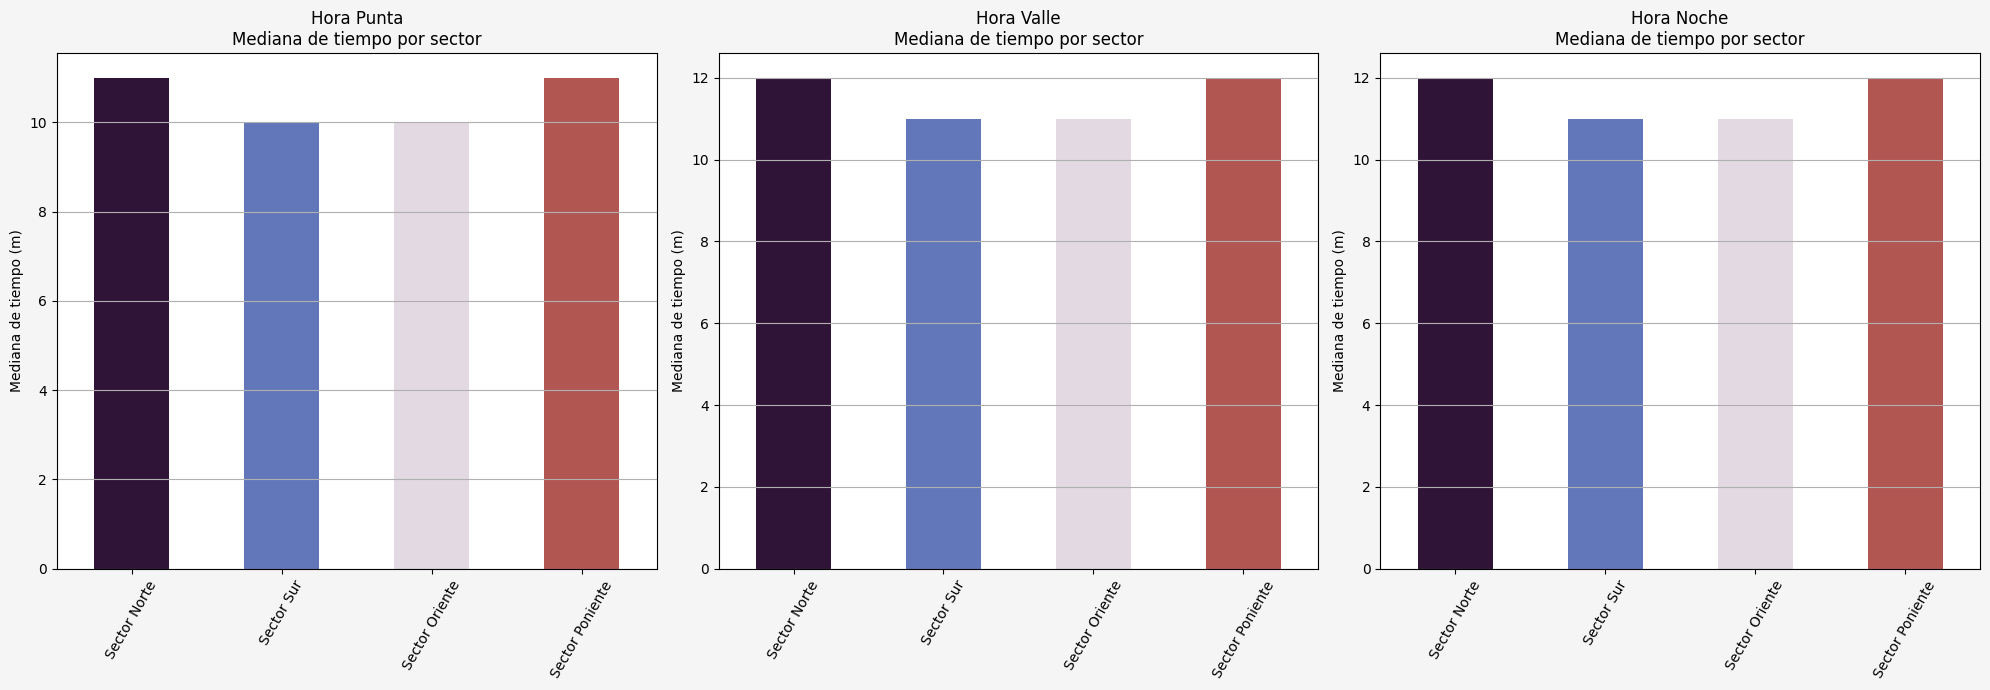

In [21]:
resultados_por_sector = {
    'Hora Punta': mediana_por_sector.loc[8],
    'Hora Valle': mediana_por_sector.loc[14],
    'Hora Noche': mediana_por_sector.loc[18]
}

# Creamos figura
fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='#f5f5f5')

# Colormap continuo para variar colores entre sectores
cmap = plt.colormaps['twilight_shifted']

for i, (hora, mediana_hora) in enumerate(resultados_por_sector.items()):
    sector = mediana_hora.index
    minutos = mediana_hora.values
    # Graficamos barras por sector
    mediana_hora.plot(
        kind='bar', 
        ax=axes[i], 
        color = [cmap(v / len(minutos)) for v in range(len(minutos))]
    )
    
    axes[i].set_title(f'{hora}\nMediana de tiempo por sector')
    axes[i].set_ylabel('Mediana de tiempo (m)')
    axes[i].tick_params(axis='x', rotation=60)
    axes[i].grid(axis='y', alpha=1)

plt.tight_layout()
plt.show()

Revisemos cuáles son los recorridos que más aparecen en nuestro DataFrame por sector, y cómo suele ser su mediana de datos según la hora:

In [22]:
# RECORRIDOS FRECUENTES NORTE
recorrido_norte['route_id'].value_counts().head(5)
b21_rec = recorrido_norte[recorrido_norte['route_id'] == 'B21']
b12_rec = recorrido_norte[recorrido_norte['route_id'] == 'B12']
b11_rec = recorrido_norte[recorrido_norte['route_id'] == 'B11']
b06_rec = recorrido_norte[recorrido_norte['route_id'] == 'B06']
rec_425 = recorrido_norte[recorrido_norte['route_id'] == '425']
b21_meters = b21_rec.groupby(by='hour').agg({'meters_distance': 'median'})
b12_meters = b12_rec.groupby('hour').agg({'meters_distance': 'median'})
b11_meters = b11_rec.groupby('hour').agg({'meters_distance': 'median'})
b06_meters = b06_rec.groupby('hour').agg({'meters_distance': 'median'})
meters_425 = rec_425.groupby('hour').agg({'meters_distance': 'median'})
b21_meters.rename(columns={'meters_distance':'B21'}, inplace=True)
b12_meters.rename(columns={'meters_distance':'B12'}, inplace=True)
b11_meters.rename(columns={'meters_distance':'B11'}, inplace=True)
b06_meters.rename(columns={'meters_distance':'B06'}, inplace=True)
meters_425.rename(columns={'meters_distance':'425'}, inplace=True)
# Concatenamos horizontalmente
meters_recorrido_norte = pd.concat([b21_meters, b12_meters, b11_meters, b06_meters, meters_425], axis=1)
meters_recorrido_norte = meters_recorrido_norte.sort_index()
# meters_recorrido_norte.drop(meters_recorrido_norte.index[2], inplace=True)
# meters_recorrido_norte.drop(meters_recorrido_norte.index[7], inplace=True)


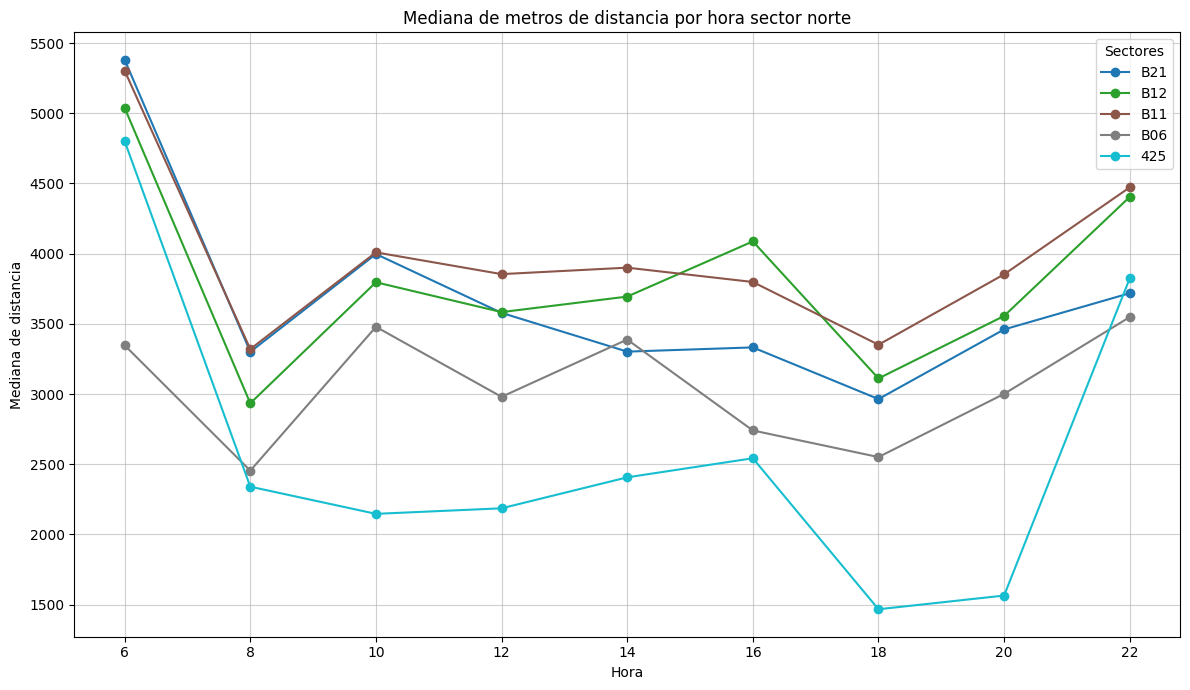

In [23]:
# CREAMOS GRÁFICO PARA RECORRIDOS DEL SECTOR NORTE
plt.figure(figsize=(12,7))

# Graficamos todas las columnas por sector
colormap = plt.colormaps['tab10']
for i, columna in enumerate(meters_recorrido_norte.columns):
    plt.plot(meters_recorrido_norte.index,
            meters_recorrido_norte[columna],
            marker='o',
            label=columna,
            color = colormap(i / (len(meters_recorrido_norte.columns) - 1)))

plt.title("Mediana de metros de distancia por hora sector norte")
plt.xlabel("Hora")
plt.ylabel("Mediana de distancia")
plt.legend(title="Sectores")
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()

plt.show()

In [24]:
# RECORRIDOS FRECUENTES SUR
recorrido_sur['route_id'].value_counts().head(5)
g09_rec = recorrido_sur[recorrido_sur['route_id'] =='G09']
rec_211 = recorrido_sur[recorrido_sur['route_id'] == '211']
g07_rec = recorrido_sur[recorrido_sur['route_id'] == 'G07']
h24_rec = recorrido_sur[recorrido_sur['route_id'] == 'H24']
rec_201 = recorrido_sur[recorrido_sur['route_id'] == '201']

g09_meters = g09_rec.groupby('hour').agg({'meters_distance': 'median'})
meters_211 = rec_211.groupby('hour').agg({'meters_distance': 'median'})
g07_meters = g07_rec.groupby('hour').agg({'meters_distance': 'median'})
h24_meters = h24_rec.groupby('hour').agg({'meters_distance': 'median'})
meters_201 = rec_201.groupby('hour').agg({'meters_distance': 'median'})
g09_meters.rename(columns={'meters_distance':'G09'}, inplace=True)
meters_211.rename(columns={'meters_distance':'211'}, inplace=True)
g07_meters.rename(columns={'meters_distance':'G07'}, inplace=True)
h24_meters.rename(columns={'meters_distance':'H24'}, inplace=True)
meters_201.rename(columns={'meters_distance':'201'}, inplace=True)
meters_recorrido_sur = pd.concat([g09_meters, meters_211, g07_meters, h24_meters, meters_201], axis=1)
meters_recorrido_sur = meters_recorrido_sur.sort_index()
# meters_recorrido_sur.drop(meters_recorrido_sur.index[2], inplace=True)
# meters_recorrido_sur.drop(meters_recorrido_sur.index[7], inplace=True)

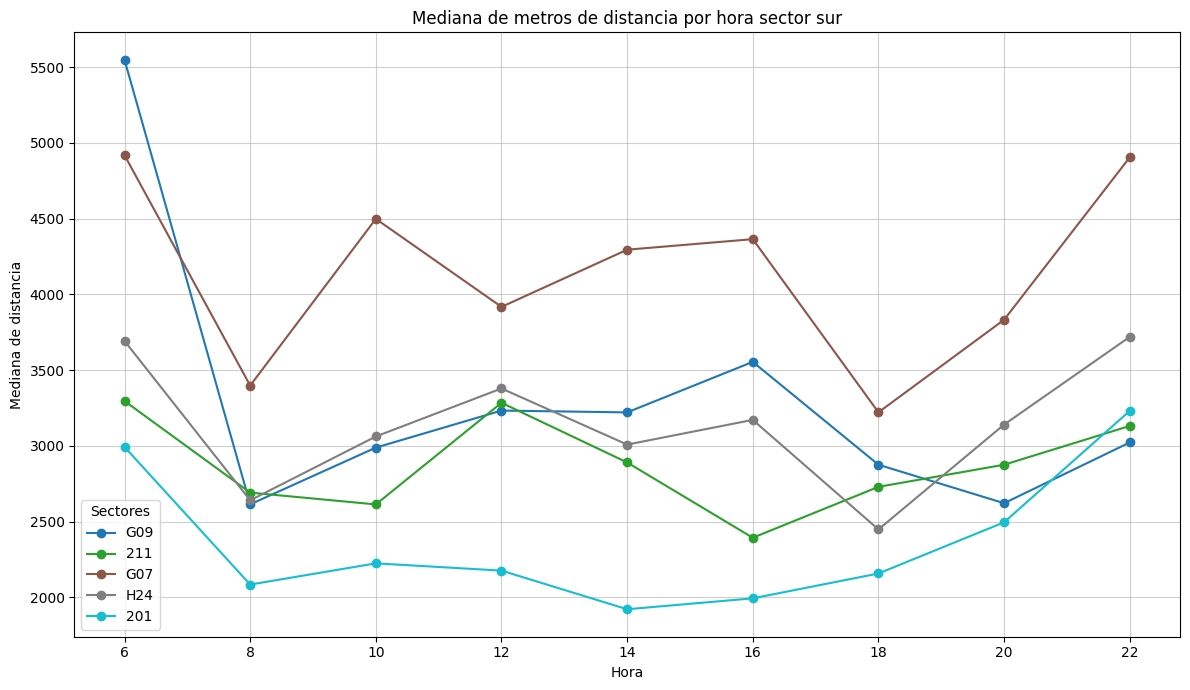

In [25]:
# GRAFICAMOS PARA SECTOR SUR
plt.figure(figsize=(12,7))

# Graficamos todas las columnas por sector
colormap = plt.colormaps['tab10']
for i, columna in enumerate(meters_recorrido_sur.columns):
    plt.plot(meters_recorrido_sur.index,
            meters_recorrido_sur[columna],
            marker='o',
            label=columna,
            color = colormap(i / (len(meters_recorrido_sur.columns) - 1)))

plt.title("Mediana de metros de distancia por hora sector sur")
plt.xlabel("Hora")
plt.ylabel("Mediana de distancia")
plt.legend(title="Sectores")
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()

plt.show()

In [26]:
# RECORRIDOS FRECUENTES PONIENTE
recorrido_poniente['route_id'].value_counts().head(5)
rec_109 = recorrido_poniente[recorrido_poniente['route_id'] == '109']
i04_rec = recorrido_poniente[recorrido_poniente['route_id'] == 'I04']
i03_rec = recorrido_poniente[recorrido_poniente['route_id'] == 'I03']
rec_110 = recorrido_poniente[recorrido_poniente['route_id'] == '110']
i10_rec = recorrido_poniente[recorrido_poniente['route_id'] == 'i10']
meters_109 = rec_109.groupby('hour').agg({'meters_distance': 'median'})
i04_meters = i04_rec.groupby('hour').agg({'meters_distance': 'median'})
i03_meters = i03_rec.groupby('hour').agg({'meters_distance': 'median'})
meters_110 = rec_110.groupby('hour').agg({'meters_distance': 'median'})
i10_meters = i10_rec.groupby('hour').agg({'meters_distance': 'median'})
meters_109.rename(columns={'meters_distance':'109'}, inplace=True)
i04_meters.rename(columns={'meters_distance':'I04'}, inplace=True)
i03_meters.rename(columns={'meters_distance':'I03'}, inplace=True)
meters_110.rename(columns={'meters_distance':'110'}, inplace=True)
i10_meters.rename(columns={'meters_distance':'I10'}, inplace=True)
meters_recorrido_poniente = pd.concat([meters_109, i04_meters, i03_meters, meters_110, i10_meters], axis=1)
meters_recorrido_poniente = meters_recorrido_poniente.sort_index()
# meters_recorrido_poniente.drop(meters_recorrido_poniente.index[2], inplace=True)
# meters_recorrido_poniente.drop(meters_recorrido_poniente.index[7], inplace=True)

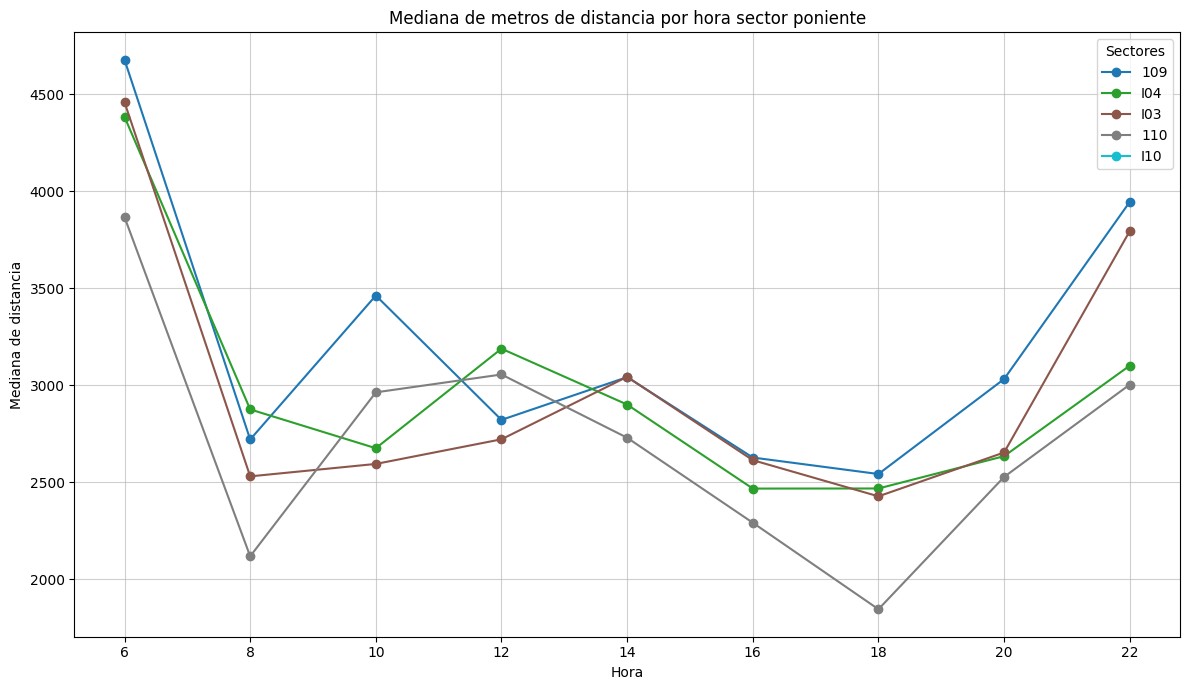

In [27]:
# GRAFICAMOS PARA SECTOR PONIENTE
plt.figure(figsize=(12,7))

# Graficamos todas las columnas por sector
colormap = plt.colormaps['tab10']
for i, columna in enumerate(meters_recorrido_poniente.columns):
    plt.plot(meters_recorrido_poniente.index,
            meters_recorrido_poniente[columna],
            marker='o',
            label=columna,
            color = colormap(i / (len(meters_recorrido_poniente.columns) - 1)))

plt.title("Mediana de metros de distancia por hora sector poniente")
plt.xlabel("Hora")
plt.ylabel("Mediana de distancia")
plt.legend(title="Sectores")
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()

plt.show()

In [28]:
# RECORRIDOS FRECUENTES ORIENTE
recorrido_oriente['route_id'].value_counts().head(5)
rec_712 = recorrido_oriente[recorrido_oriente['route_id'] == '712']
rec_225 = recorrido_oriente[recorrido_oriente['route_id'] == '225']
d10_rec = recorrido_oriente[recorrido_oriente['route_id'] == 'D10']
rec_124 = recorrido_oriente[recorrido_oriente['route_id'] == '124']
rec_325 = recorrido_oriente[recorrido_oriente['route_id'] == '418']
meters_712 = rec_712.groupby('hour').agg({'meters_distance': 'median'})
meters_225 = rec_225.groupby('hour').agg({'meters_distance': 'median'})
d10_meters = d10_rec.groupby('hour').agg({'meters_distance': 'median'})
meters_124 = rec_124.groupby('hour').agg({'meters_distance': 'median'})
meters_325 = rec_325.groupby('hour').agg({'meters_distance': 'median'})
meters_712.rename(columns={'meters_distance':'712'}, inplace=True)
meters_225.rename(columns={'meters_distance':'225'}, inplace=True)
d10_meters.rename(columns={'meters_distance':'D10'}, inplace=True)
meters_124.rename(columns={'meters_distance':'124'}, inplace=True)
meters_325.rename(columns={'meters_distance':'325'}, inplace=True)
meters_recorrido_oriente = pd.concat([meters_712, meters_225, d10_meters, meters_124, meters_325], axis=1)
meters_recorrido_oriente = meters_recorrido_oriente.sort_index()
# meters_recorrido_oriente.drop(meters_recorrido_oriente.index[2], inplace=True)
# meters_recorrido_oriente.drop(meters_recorrido_oriente.index[7], inplace=True)

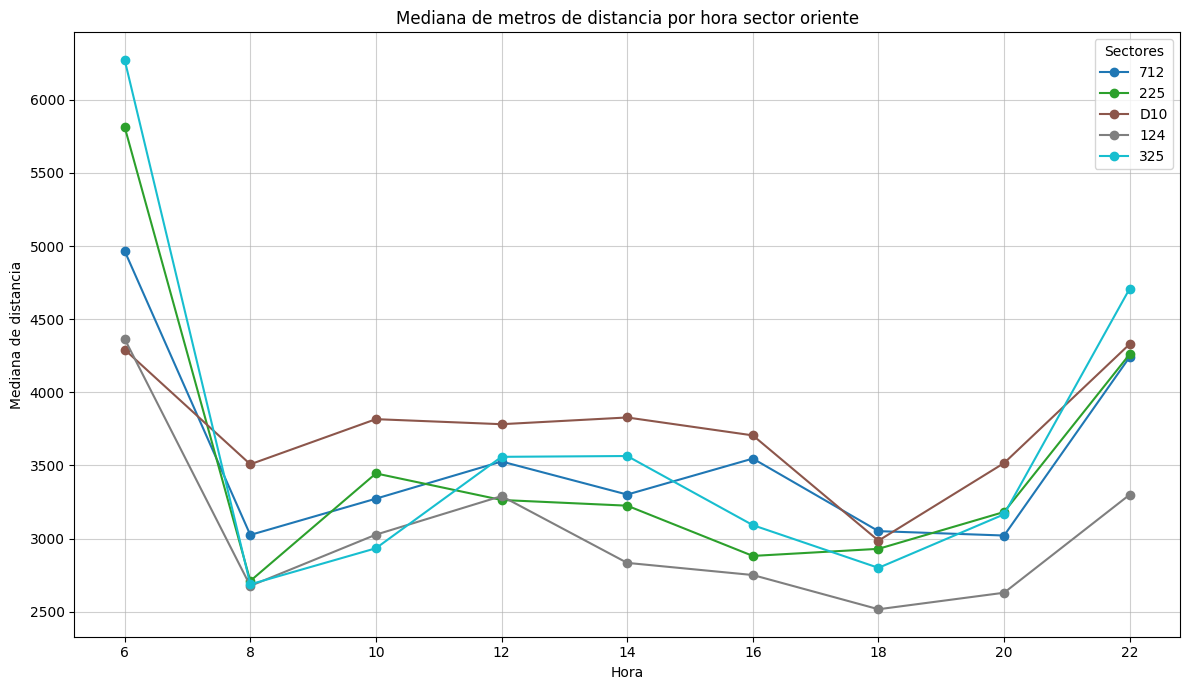

In [29]:
# GRAFICAMOS PARA SECTOR ORIENTE
plt.figure(figsize=(12,7))

# Graficamos todas las columnas por sector
colormap = plt.colormaps['tab10']
for i, columna in enumerate(meters_recorrido_oriente.columns):
    plt.plot(meters_recorrido_oriente.index,
            meters_recorrido_oriente[columna],
            marker='o',
            label=columna,
            color = colormap(i / (len(meters_recorrido_oriente.columns) - 1)))

plt.title("Mediana de metros de distancia por hora sector oriente")
plt.xlabel("Hora")
plt.ylabel("Mediana de distancia")
plt.legend(title="Sectores")
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()

plt.show()

### ANÁLISIS PARCIAL METRO
Dado que ya tenemos cierta información que nos puede ser de bastante utilidad en cuanto a las micros, veamos ahora qué pasa con el metro y la situación de estaciones no operativas:

In [30]:
metro_no_operativo = metro_data[metro_data['status_code'] != 0]
metro_no_operativo.tail(4)

,line_id,station_id,name,status_code,status_description,date
3278,L5,vicente-valdes,Vicente Valdés,1,Estación Temporalmente Cerrada,2025-10-13 22:30:03.537406
15172,L1,universidad-catolica,Universidad Católica,1,Estación Temporalmente Cerrada,2025-10-18 22:30:03.835550
15315,L1,universidad-catolica,Universidad Católica,1,Estación Temporalmente Cerrada,2025-10-19 06:30:03.200687
15458,L1,universidad-catolica,Universidad Católica,1,Estación Temporalmente Cerrada,2025-10-19 07:30:03.785781


In [31]:
# METROS NO OPERATIVOS LINEA 1
no_opera_l1 = metro_no_operativo[metro_no_operativo['line_id'] == 'L1']
no_opera_l1.head(10)
print(f'De la l1, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas {len(no_opera_l1)} veces')


De la l1, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas 3 veces


In [32]:
no_opera_l5 = metro_no_operativo[metro_no_operativo['line_id'] == 'L5']
no_opera_l5.head(10)
print(f'De la l5, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas {len(no_opera_l5)} veces')


De la l5, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas 27 veces


In [33]:
no_opera_l3 = metro_no_operativo[metro_no_operativo['line_id'] == 'L3']
print(f'De la l3, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas {len(no_opera_l3)} veces')


De la l3, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas 0 veces


In [34]:
no_opera_l4 = metro_no_operativo[metro_no_operativo['line_id'] == 'L4']
print(f'De la l4, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas {len(no_opera_l4)} veces')


De la l4, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas 0 veces


In [35]:
no_opera_l2 = metro_no_operativo[metro_no_operativo['line_id'] == 'L2']
print(f'De la l2, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas {len(no_opera_l2)} veces')


De la l2, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas 0 veces


In [36]:
no_opera_l6 = metro_no_operativo[metro_no_operativo['line_id'] == 'L6']
print(f'De la l6, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas {len(no_opera_l6)} veces')


De la l6, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas 0 veces


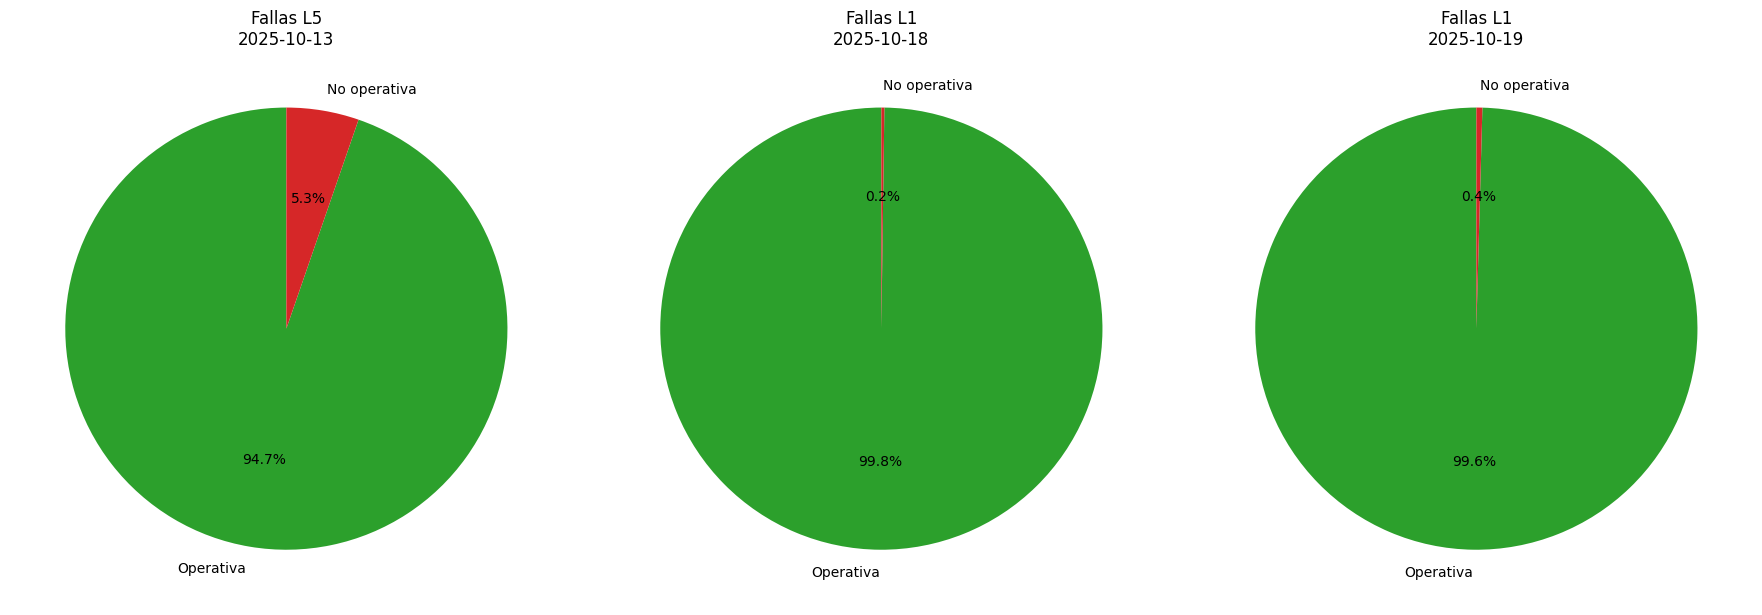

In [37]:
# Hacemos gráficos respectivos a los días en los que hubo fallas
fallas = [
    {"linea": "L5", "fecha": "2025-10-13"},
    {"linea": "L1", "fecha": "2025-10-18"}, 
    {"linea": "L1", "fecha": "2025-10-19"}  
]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Filtramos solo registros de días de las fallas
for i, falla in enumerate(fallas):
    # Filtrar datos para esa línea y fecha
    df_falla = metro_data[(metro_data["line_id"] == falla["linea"]) & 
                          (metro_data["date"].str.startswith(falla["fecha"]))]
    total = len(df_falla)
    no_op = len(df_falla[df_falla["status_code"] != 0])
    op = total - no_op
    
    valores = [op, no_op]
    etiquetas = ["Operativa", "No operativa"]
    colors = ["#2ca02c", "#d62728"]
    
    axes[i].pie(valores, labels=etiquetas, autopct='%1.1f%%', startangle=90, colors=colors)
    axes[i].set_title(f"Fallas {falla["linea"]}\n{falla["fecha"]}")

plt.tight_layout()
plt.show()

Durante el tiempo de recolección de datos (desde el 12-10-2025 hasta el 25-10-25) hubo casos mínimos donde determinadas estaciones de metro estuvieron no operativas. En dicho contexto, fue la l5 la que presentó mayor cantidad de problemas durante el día 13-10, mientras que en l1 la estación no operativa fue la de Universidad Católica, que estuvo inactiva desde las 22:30 del 18-10 hasta las 7:30 del 19-10; ello muestra lentitud en la restauración del servicio.

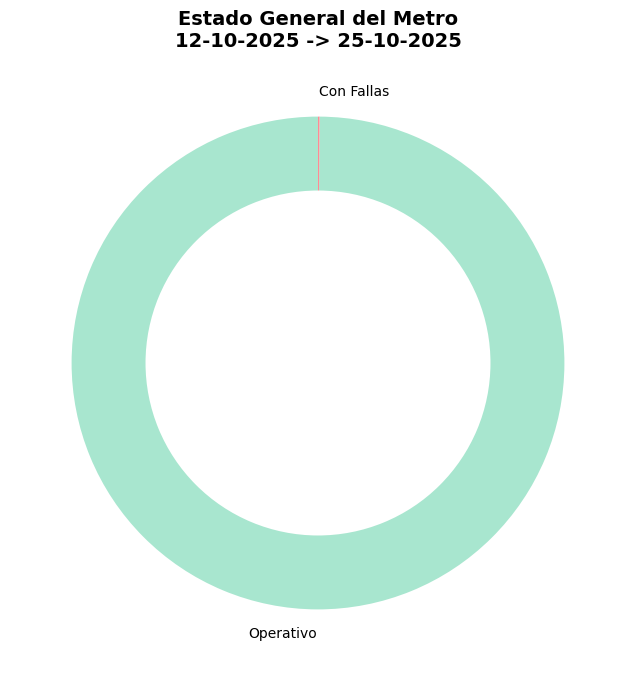

In [38]:
fig, ax = plt.subplots(figsize=(8, 8))
no_funcionan = len(metro_data[metro_data['status_code'] == 1])
funcionan = len(metro_data) - no_funcionan
valores = [funcionan, no_funcionan]
etiquetas = ['Operativo', 'Con Fallas']
colors = ['#A8E6CF', '#FF8B94']
wedges, texts, autotexts = ax.pie(valores, labels=etiquetas, autopct='%1.1f%%',
                                 colors=colors, startangle=90, 
                                 wedgeprops=dict(width=0.3))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.title('Estado General del Metro\n12-10-2025 -> 25-10-2025', fontsize=14, fontweight='bold')
plt.show()

In [39]:
print(f'El porcentaje de falla del metro durante el tiempo de extracción de datos, corresponde al {round((no_funcionan/len(metro_data)) * 100, 2)}%')

El porcentaje de falla del metro durante el tiempo de extracción de datos, corresponde al 0.1%


## DENSIDAD POBLACIONAL
Podemos utilizar los datos ya obtenidos para poder determinar cosas interesantes: Sectores y/o comunas específicas donde el servicio es malo, aquellos recorridos que por lo general estaba a menor distancia, entre otras cosas. Pero para responder correctamente las preguntas planteadas, es necesario saber en qué zonas afecta más el tener un mal servicio de transporte público; contestar dicha pregunta y otras relacionadas al impacto social de la calidad de servicio de transporte, utilizaremos la densidad poblacional por comuna.

In [40]:
# densidad comunal: 
densidad_comunas = pd.read_csv(Path("..", "data", "densidad_2025.csv"))
densidad_comunas.drop(columns=['Unnamed: 0'], inplace=True)
densidad_comunas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cut_region            33 non-null     int64  
 1   cut_provincia         33 non-null     int64  
 2   cut_comuna            33 non-null     int64  
 3   comuna                33 non-null     object 
 4   año                   33 non-null     int64  
 5   población             33 non-null     int64  
 6   km^2                  33 non-null     int64  
 7   densidad_poblacional  33 non-null     float64
dtypes: float64(1), int64(6), object(1)
memory usage: 2.2+ KB


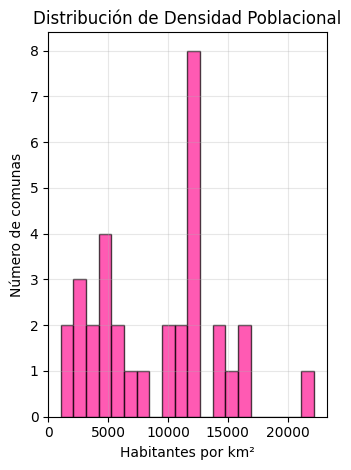

In [41]:
# Graficamos la cantidad de densidad poblacional en las comunas:
plt.subplot(1, 2, 1)
plt.hist(densidad_comunas["densidad_poblacional"], bins=20, alpha=0.7, color="deeppink", edgecolor="black")
plt.xlabel("Habitantes por km²")
plt.ylabel("Número de comunas")
plt.title("Distribución de Densidad Poblacional")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

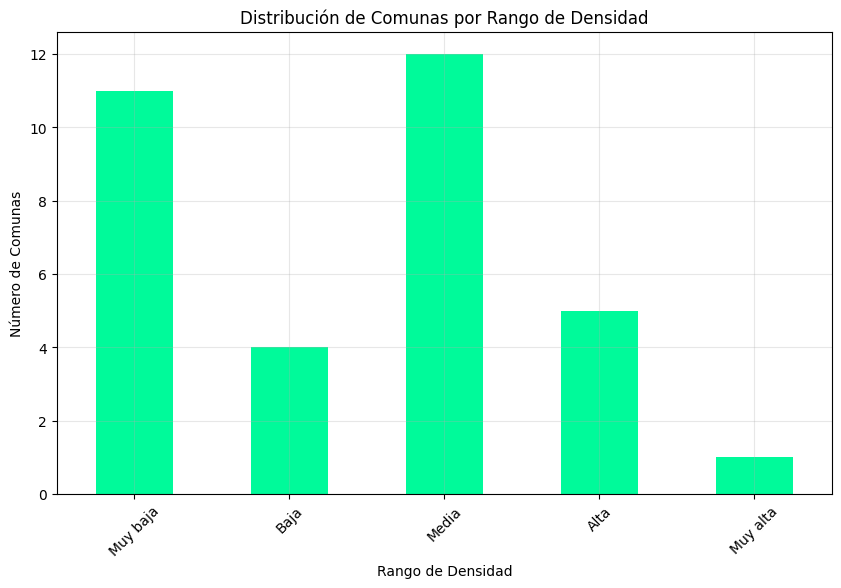

In [42]:
densidad_comunas["rango_densidad"] = pd.cut(densidad_comunas["densidad_poblacional"], 
                                      bins=5, 
                                      labels=["Muy baja", "Baja", "Media", "Alta", "Muy alta"])

plt.figure(figsize=(10, 6))
densidad_comunas["rango_densidad"].value_counts().sort_index().plot(kind="bar", color="mediumspringgreen")
plt.title("Distribución de Comunas por Rango de Densidad")
plt.xlabel("Rango de Densidad")
plt.ylabel("Número de Comunas")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
# Las 8 comunas con mayor densidad poblacional:
densidad_top_5 = densidad_comunas.nlargest(10, "densidad_poblacional")[["comuna", "densidad_poblacional"]].reset_index()
densidad_top_5.drop(columns=['index'], inplace=True)
densidad_top_5

,comuna,densidad_poblacional
0,Independencia,22198.0
1,Estación Central,15989.0
2,Ñuñoa,15913.0
3,San Miguel,14839.0
4,Lo Prado,14460.0
5,San Ramón,13820.0
6,Cerro Navia,12607.0
7,Lo Espejo,12472.0
8,Recoleta,12364.0
9,Conchalí,12332.0


In [44]:
menor_densidad = densidad_comunas.nsmallest(10, "densidad_poblacional")[["comuna", "densidad_poblacional"]].reset_index()
menor_densidad.drop(columns=['index'], inplace=True)

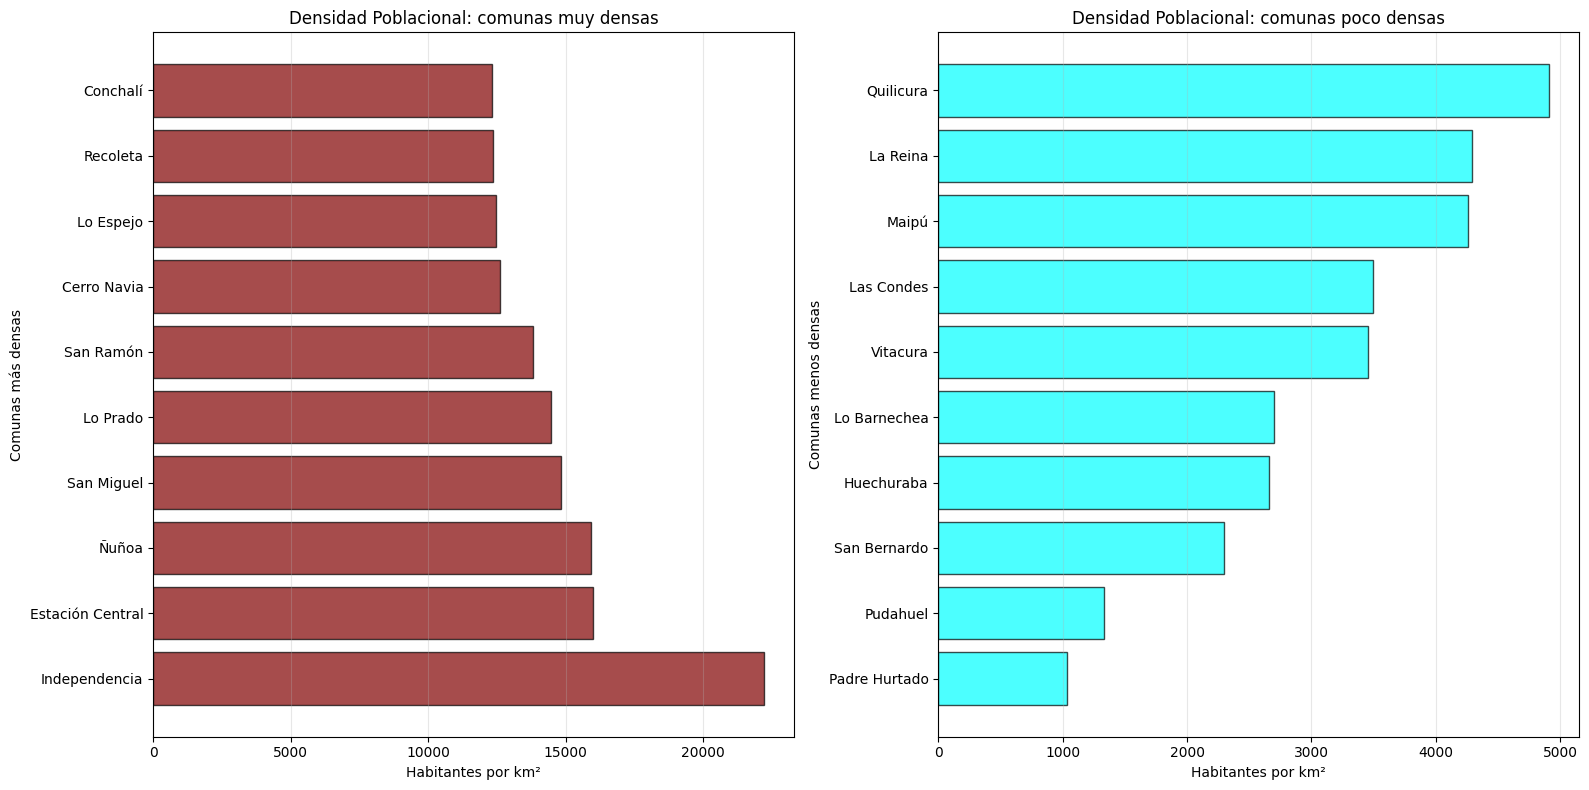

In [45]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
equis_1 = plt.barh(densidad_top_5["comuna"], densidad_top_5["densidad_poblacional"], alpha=0.7, color="maroon", edgecolor="black")
plt.xlabel("Habitantes por km²")
plt.ylabel("Comunas más densas")
plt.title("Densidad Poblacional: comunas muy densas")
plt.grid(True, alpha=0.3, axis="x")

plt.subplot(1, 2, 2)
equis_2 = plt.barh(menor_densidad["comuna"], menor_densidad["densidad_poblacional"], alpha=0.7, color="aqua", edgecolor="black")
plt.xlabel("Habitantes por km²")
plt.ylabel("Comunas menos densas")
plt.title("Densidad Poblacional: comunas poco densas")
plt.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

### Respuestas a preguntas del proyecto

In [46]:
# Pregunta 5: ¿Cuáles son los recorridos de RED con frecuencias más irregulares de Santiago?
# Revisamos recorridos de frecuencias irregulares sin separar por sector:
# Contar cuántas veces cada recorrido tuvo demora >= 12 min
retraso_en_recorrido = recorridos_limpios[
    recorridos_limpios["min_arrival_time"] >= 15
].copy()
# cuantas veces los recorridos estuvieron dentro de dicho rango
count_retraso = retraso_en_recorrido["route_id"].value_counts().reset_index()
count_retraso.columns = ["route_id", "total_demoras"]
retraso_en_recorrido = pd.merge(retraso_en_recorrido, count_retraso, on="route_id", how="left")
retraso_en_comunas = retraso_en_recorrido[["comuna", "route_id"]].value_counts().reset_index()
retraso_en_comunas.columns = ["comuna", "route_id", "total_por_comuna"]
retraso_en_recorrido = pd.merge(retraso_en_recorrido, retraso_en_comunas, on=["comuna", "route_id"], how="left")
demoras_por_recorrido = retraso_en_recorrido.sort_values(["total_demoras", 'min_arrival_time'],ascending=[False,False])

demoras_por_recorrido.head()

,bus_stop_code,route_id,bus_id,meters_distance,min_arrival_time,max_arrival_time,id,codinfra,comuna,nombre_par,n_servicios,servicios,lan,lon,hour,date_only,total_demoras,total_por_comuna
41945,PJ1721,418,SJPD-97,31269,99,60,7002,L-10-38-10-OP,PUDAHUEL,R�o Itata / esq. Av. J. Guzm�n Riesco,9,508;514;J07;J07e;J10;407;422;422c;412,-70.772098,-33.428441,18,2025-11-07,2596,553
6227,PD1446,418,PFVH-15,25311,80,60,9752,L-18-35-14-PO,ÑUÑOA,Emilia T�llez / esq. Coventry,1,D16,-70.581718,-33.441719,16,2025-11-01,2596,91
6228,PD1446,418,LXWP-72,25311,80,60,9752,L-18-35-14-PO,ÑUÑOA,Emilia T�llez / esq. Coventry,1,D16,-70.581718,-33.441719,16,2025-11-01,2596,91
25781,PC382,418,PFVH-11,23624,75,60,8579,T-14-170-NS-15,PROVIDENCIA,Parada 1 / (M) Crist�bal @ Col�n,4,432N;429;418;412,-70.591391,-33.426229,22,2025-11-04,2596,482
33148,PE504,418,PFYC-53,23504,74,60,3036,L-33-41-30-PO,LA FLORIDA,Mar�a Ang�lica / esq. Mar�a Cristina,4,126;118;418;D26,-70.548865,-33.514560,6,2025-11-06,2596,127


In [47]:
print(f"Por lo tanto, los recorridos RED más irregulares EN FRECUENCIA: {[retraso for retraso in count_retraso["route_id"][:10]]}")

Por lo tanto, los recorridos RED más irregulares EN FRECUENCIA: ['418', '412', '712', '514', '429', '106', '421', 'D10', '511', 'J07']


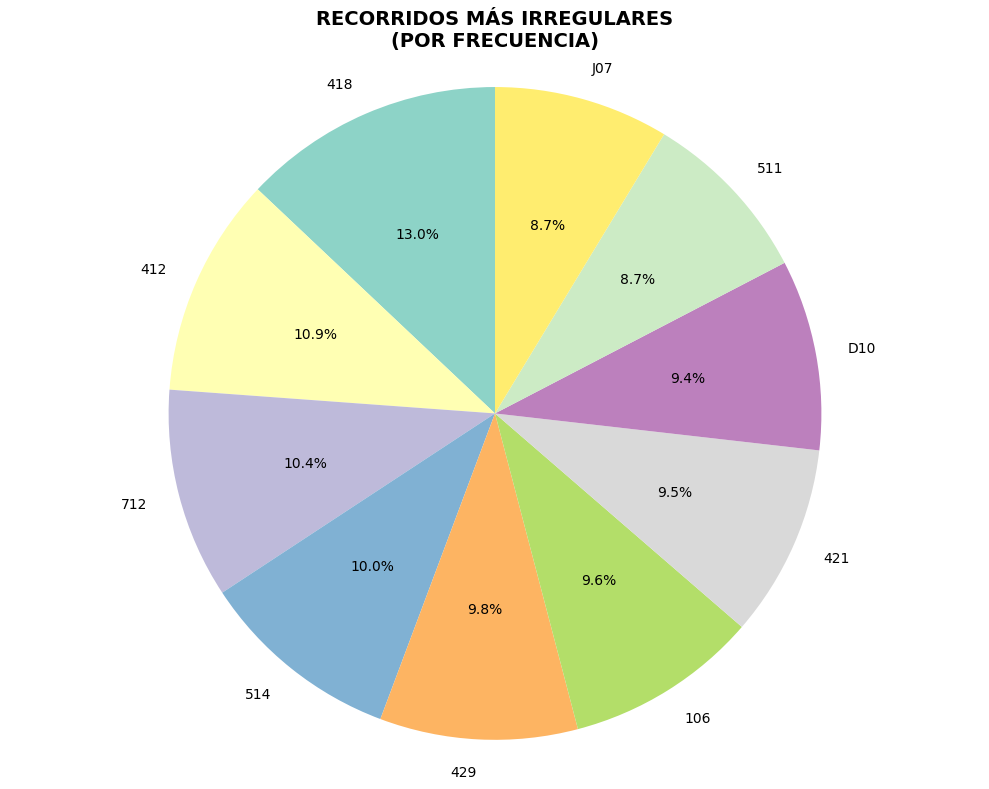

In [48]:
top_demora_frecuencial = count_retraso.head(10)
plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(top_demora_frecuencial)))
plt.pie(top_demora_frecuencial["total_demoras"], 
        labels=top_demora_frecuencial["route_id"],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
plt.title("RECORRIDOS MÁS IRREGULARES\n(POR FRECUENCIA)", 
          fontsize=14, fontweight='bold')
plt.axis("equal")
plt.tight_layout()
plt.show()

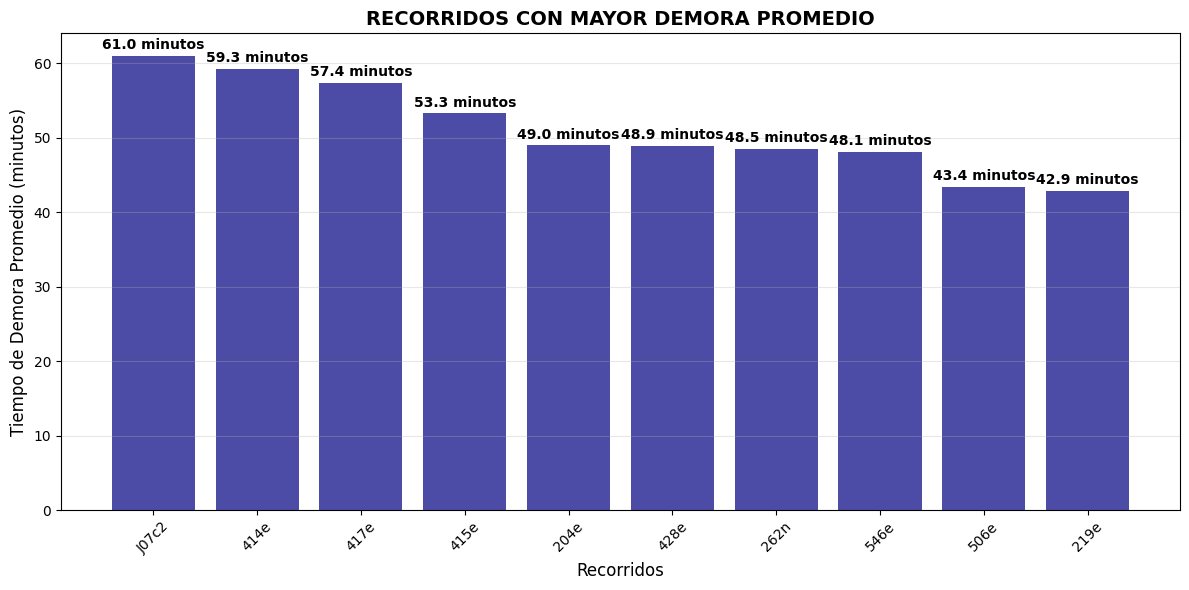

In [49]:
# Evaluamos los recorridos con mayor cantidad de retrasos en promedio
top_10demoras = retraso_en_recorrido.groupby("route_id").agg({
    "min_arrival_time": "mean",
    "total_demoras": "first"}).round(1).nlargest(10, "min_arrival_time")

plt.figure(figsize=(12, 6))
bars = plt.bar(top_10demoras.index.astype(str), top_10demoras["min_arrival_time"], 
               color='navy', alpha=0.7)
for bar, demora in zip(bars, top_10demoras["min_arrival_time"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f"{demora} minutos", ha="center", va="bottom", fontweight="bold")

plt.title("RECORRIDOS CON MAYOR DEMORA PROMEDIO", fontsize=14, fontweight="bold")
plt.xlabel("Recorridos", fontsize=12)
plt.ylabel("Tiempo de Demora Promedio (minutos)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
top_10demoras
print(f"Por lo tanto, los recorridos RED más irregulares EN PROMEDIO: {[demora for demora in top_10demoras.index[:10]]}")

Por lo tanto, los recorridos RED más irregulares EN PROMEDIO: ['J07c2', '414e', '417e', '415e', '204e', '428e', '262n', '546e', '506e', '219e']


In [51]:
# respuesta 4
# ¿La frecuencia del transporte por horario es proporcional a la cantidad de personas que necesitan movilizarse en tales horarios?

# Primeramente, no tenemos datos de la cantidad de personas que utilizan el servicio de transporte público a ciertas horas, entonces
# vamos a definir una nueva columna que selecciona el periodo, es decir, diferenciar entre horario punta y valle.
recorridos_analisis = recorridos_limpios.copy()
recorridos_analisis["periodo_horario"] = recorridos_analisis["hour"].apply(lambda x: "punta_mañana" if 6 <= x <= 9 else
                                                                         "punta_noche" if 18 <= x <= 21 else
                                                                         "valle_mañana" if 10 <= x <= 12 else
                                                                         "valle_tarde" if 14 <= x <= 16
                                                                         else "noche")
# Ahora, debemos definir si los días son laborales o de descanso
recorridos_analisis["dia_correspondiente"] = pd.to_datetime(recorridos_analisis["date_only"]).dt.day_name()
recorridos_analisis["tipo_dia"] = recorridos_analisis["dia_correspondiente"].apply(lambda x: "descanso" if x in ["Saturday", "Sunday"] else "laboral")

In [52]:
# Ahora, vamos a analizar en los días (sin separar por ahora en día laboral y día de descanso)los períodos de horario (punta_mañana, valle_tarde, etc)
analisis_df = recorridos_analisis.groupby(["date_only", "periodo_horario"]).agg({
    "bus_id": ["count", "nunique"],
    "min_arrival_time": "median",
}).round(2)
# Aplanar columnas multi-nivel
analisis_df.columns = ["total_servicios", "micros_unicas", "tiempo_espera_mediana"]
analisis_df = analisis_df.reset_index()
analisis_df

,date_only,periodo_horario,total_servicios,micros_unicas,tiempo_espera_mediana
0,2025-10-12,noche,270,240,12.0
1,2025-10-12,punta_noche,3616,1728,11.0
2,2025-10-13,noche,3615,1956,9.0
3,2025-10-13,punta_mañana,9076,4105,8.0
4,2025-10-13,punta_noche,5608,3325,9.0
...,...,...,...,...,...
128,2025-11-07,valle_mañana,10328,4387,6.0
129,2025-11-07,valle_tarde,9242,4243,6.0
130,2025-11-08,punta_mañana,613,543,11.0
131,2025-11-08,valle_mañana,2158,1522,8.0


En el DataFrame analisis_df, tenemos la cantidad de servicios ofrecidos en la región metropolitana SIN SEPARAR POR COMUNA, según el período del día. Por otra parte, tenemos las micros que cumplen sus respectivos recorridos en dicho horario (usamos el código específico de la micro para evitar duplicados) 

In [53]:
frecuencia_mean_general = analisis_df.groupby("periodo_horario").agg({"total_servicios": ["count", "median"],
                                                                      "tiempo_espera_mediana": ["median"]}).round(2)
# Empezamos a relacionar las variables
median_total_am = (frecuencia_mean_general.loc["punta_mañana", ("total_servicios", "median")] / 2)
median_total_valle_am = (frecuencia_mean_general.loc["valle_mañana", ("total_servicios", "median")] / 2)
median_total_valle_pm = (frecuencia_mean_general.loc["valle_tarde", ("total_servicios", "median")] / 2)
median_total_pm = (frecuencia_mean_general.loc["punta_noche", ("total_servicios", "median")] / 2)
median_total_noche = frecuencia_mean_general.loc["noche", ("total_servicios", "median")]
median_time_am = (frecuencia_mean_general.loc["punta_mañana", ("tiempo_espera_mediana", "median")] / 2)
median_time_valle_am = ( frecuencia_mean_general.loc["valle_mañana", ("tiempo_espera_mediana", "median")] / 2)
median_time_valle_pm = ( frecuencia_mean_general.loc["valle_tarde", ("tiempo_espera_mediana", "median")] / 2)
median_time_pm = (frecuencia_mean_general.loc["punta_noche", ("tiempo_espera_mediana", "median")] / 2)
median_time_noche = frecuencia_mean_general.loc["noche", ("tiempo_espera_mediana", "median")]
cocientes = {"cociente_am_valle_am": round(median_total_am / median_total_valle_am, 2),
             "cociente_pm_valle_pm": round(median_total_pm / median_total_valle_pm, 2),
             "cociente_pm_noche": round(median_total_pm/median_total_noche, 2),
             "cociente_am_pm": round(median_total_am/median_total_pm, 2)}

calidad_transporte = {"tiempo_am_valle_am": round(median_time_am/median_time_valle_am, 2),
                      "tiempo_pm_valle_pm": round(median_time_pm/median_time_valle_pm,2),
                      "tiempo_pm_noche": round(median_time_pm/median_time_noche,2),
                      "tiempo_am_pm": round(median_time_am/median_time_pm,2)}

In [54]:
print("DISPONIBILIDAD DEL SERVICIO (SIN SEPARAR EN DÍA LABORAL Y DE DESCANSO)")
for comparacion, cociente in cocientes.items():
    print(f"Proporcionalidad en {comparacion}: {cociente}")
print("CALIDAD DEL SERVICIO")
for llave, median_time in calidad_transporte.items():
    print(f"Proporcionalidad en {llave}: {median_time}")

DISPONIBILIDAD DEL SERVICIO (SIN SEPARAR EN DÍA LABORAL Y DE DESCANSO)
Proporcionalidad en cociente_am_valle_am: 0.78
Proporcionalidad en cociente_pm_valle_pm: 1.16
Proporcionalidad en cociente_pm_noche: 1.02
Proporcionalidad en cociente_am_pm: 0.81
CALIDAD DEL SERVICIO
Proporcionalidad en tiempo_am_valle_am: 1.0
Proporcionalidad en tiempo_pm_valle_pm: 1.0
Proporcionalidad en tiempo_pm_noche: 0.44
Proporcionalidad en tiempo_am_pm: 1.0


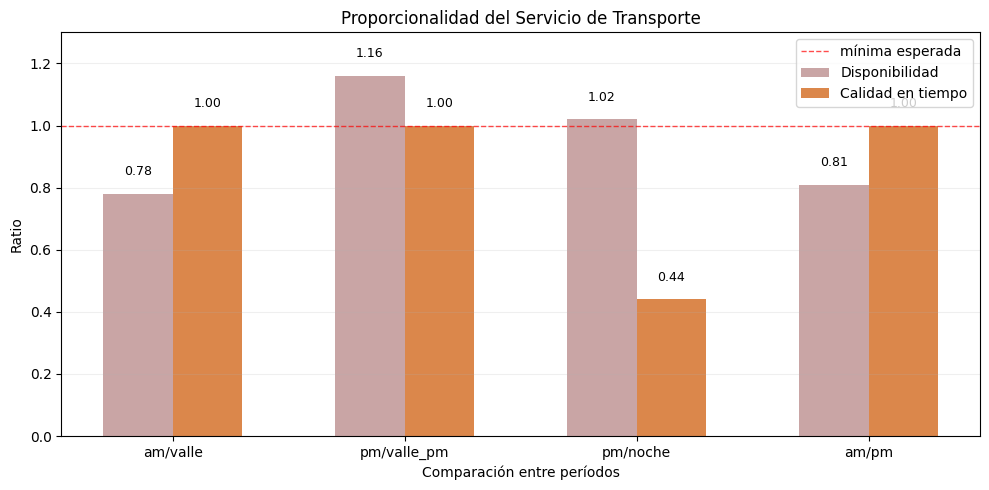

In [57]:
disponibilidad = [0.78, 1.16, 1.02, 0.81]  # servicios por hora
calidad = [1.0, 1.0, 0.44, 1.0]            # tiempos de espera
labels = ["am/valle", "pm/valle_pm", "pm/noche", "am/pm"]

x = np.arange(len(labels))
plt.figure(figsize=(10, 5))

# graficar variable cocientes
plt.bar(x - 0.15, disponibilidad, 0.3, label="Disponibilidad", 
        color="rosybrown", alpha=0.8)
# graficar calidad_transportes
plt.bar(x + 0.15, calidad, 0.3, label="Calidad en tiempo", 
        color="chocolate", alpha=0.8)


plt.axhline(y=1.0, color="red", linestyle="--", linewidth=1, 
            label="mínima esperada", alpha=0.7)
plt.xlabel("Comparación entre períodos")
plt.ylabel("Ratio")
plt.title("Proporcionalidad del Servicio de Transporte")
plt.xticks(x, labels)
plt.legend()

for i, (disp, cal) in enumerate(zip(disponibilidad, calidad)):
    plt.text(i - 0.15, disp + 0.05, f'{disp:.2f}', 
             ha="center", va="bottom", fontsize=9)
    plt.text(i + 0.15, cal + 0.05, f'{cal:.2f}', 
             ha="center", va="bottom", fontsize=9)

plt.grid(True, alpha=0.2, axis="y")
plt.ylim(0, 1.3)
plt.tight_layout()
plt.show()

In [56]:
# PARA LA 4
conteo_comunas = recorridos_limpios["comuna"].value_counts()
print(conteo_comunas, len(conteo_comunas))
comunas_ordenadas_x_población = densidad_comunas.copy().sort_values(by="población", ascending=False)
print(comunas_ordenadas_x_población["comuna"].str.upper(), len(conteo_comunas))
print(comunas_ordenadas_x_población["comuna"].str.upper().isin(conteo_comunas), len(conteo_comunas))

comuna
MAIPÚ                  64446
PUENTE ALTO            59557
SANTIAGO               53760
LA FLORIDA             40930
LAS CONDES             40029
SAN BERNARDO           30224
PEÑALOLÉN              30017
PUDAHUEL               28867
LA PINTANA             28317
QUILICURA              27578
ESTACIÓN CENTRAL       24787
ÑUÑOA                  23968
QUINTA NORMAL          22422
RENCA                  21455
PROVIDENCIA            20241
CERRO NAVIA            19611
EL BOSQUE              18806
CERRILLOS              18328
CONCHALÍ               17580
LA REINA               17424
RECOLETA               17010
MACUL                  16376
LA GRANJA              14604
LA CISTERNA            14283
LO ESPEJO              14199
SAN MIGUEL             13809
LO PRADO               13230
HUECHURABA             13218
VITACURA               12925
PEDRO AGUIRRE CERDA    11557
SAN RAMÓN              11098
SAN JOAQUÍN            11026
INDEPENDENCIA          10810
LO BARNECHEA            9469
PADRE H